In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ═══════════════════════════════════════════
#  DÖVİZ KURU — güncellenmesi gerekirse burayı değiştirin
EURO_TO_TL = 52.72
# ═══════════════════════════════════════════

plt.rcParams['figure.figsize'] = (13, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

print(f'✅ Kütüphaneler yüklendi.')
print(f'💱 Aktif kur: 1 € = {EURO_TO_TL} ₺')

✅ Kütüphaneler yüklendi.
💱 Aktif kur: 1 € = 52.72 ₺


In [2]:
# ⚠️  CSV dosyası bu notebook ile AYNI klasörde olmalı
df = pd.read_csv('laptop_price - dataset.csv')

print(f'📊 Boyut : {df.shape[0]} satır × {df.shape[1]} sütun')
print(f'\n📋 Sütunlar:')
for c in df.columns:
    print(f'   • {c}')

📊 Boyut : 1275 satır × 15 sütun

📋 Sütunlar:
   • Company
   • Product
   • TypeName
   • Inches
   • ScreenResolution
   • CPU_Company
   • CPU_Type
   • CPU_Frequency (GHz)
   • RAM (GB)
   • Memory
   • GPU_Company
   • GPU_Type
   • OpSys
   • Weight (kg)
   • Price (Euro)


In [3]:
df.head()

,Company,Product,TypeName,Inches,ScreenResolution,CPU_Company,CPU_Type,CPU_Frequency (GHz),RAM (GB),Memory,GPU_Company,GPU_Type,OpSys,Weight (kg),Price (Euro)
0,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel,Core i5,2.3,8,128GB SSD,Intel,Iris Plus Graphics 640,macOS,1.37,1339.69
1,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel,Core i5,1.8,8,128GB Flash Storage,Intel,HD Graphics 6000,macOS,1.34,898.94
2,HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel,Core i5 7200U,2.5,8,256GB SSD,Intel,HD Graphics 620,No OS,1.86,575.00
3,Apple,MacBook Pro,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel,Core i7,2.7,16,512GB SSD,AMD,Radeon Pro 455,macOS,1.83,2537.45
4,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel,Core i5,3.1,8,256GB SSD,Intel,Iris Plus Graphics 650,macOS,1.37,1803.60


In [4]:
missing = pd.DataFrame({
    'Tip'          : df.dtypes,
    'Eksik'        : df.isnull().sum(),
    'Eksik %'      : (df.isnull().sum()/len(df)*100).round(2)
})
print(missing)

                         Tip  Eksik  Eksik %
Company                  str      0      0.0
Product                  str      0      0.0
TypeName                 str      0      0.0
Inches               float64      0      0.0
ScreenResolution         str      0      0.0
CPU_Company              str      0      0.0
CPU_Type                 str      0      0.0
CPU_Frequency (GHz)  float64      0      0.0
RAM (GB)               int64      0      0.0
Memory                   str      0      0.0
GPU_Company              str      0      0.0
GPU_Type                 str      0      0.0
OpSys                    str      0      0.0
Weight (kg)          float64      0      0.0
Price (Euro)         float64      0      0.0


In [5]:
df_clean = df.copy()

# Sütun isimlerini standartlaştır
df_clean.columns = (df_clean.columns
                    .str.strip().str.lower().str.replace(' ', '_'))

cols = df_clean.columns.tolist()
print('Standartlaştırılmış sütunlar:', cols)

Standartlaştırılmış sütunlar: ['company', 'product', 'typename', 'inches', 'screenresolution', 'cpu_company', 'cpu_type', 'cpu_frequency_(ghz)', 'ram_(gb)', 'memory', 'gpu_company', 'gpu_type', 'opsys', 'weight_(kg)', 'price_(euro)']


In [6]:
import re

def extract_number(val):
    """String içinden ilk sayıyı çıkarır."""
    try:
        return float(str(val).replace(',','.').replace('$','').replace('€','').strip())
    except:
        nums = re.findall(r'[\d.]+', str(val))
        return float(nums[0]) if nums else np.nan

# Fiyat sütununu bul
price_eur_col = next((c for c in cols if 'price' in c or 'fiyat' in c), cols[-1])
price_col     = 'fiyat_tl'   # TL sütunu adı

# Euro'dan TL'ye çevir
df_clean[price_eur_col] = df_clean[price_eur_col].apply(extract_number)
df_clean.dropna(subset=[price_eur_col], inplace=True)
df_clean[price_col] = (df_clean[price_eur_col] * EURO_TO_TL).round(0)

# Marka sütununu bul
cat_cols     = df_clean.select_dtypes('object').columns.tolist()
brand_col    = next((c for c in cat_cols
                     if any(x in c for x in ['brand','company','marka'])), 
                    cat_cols[0] if cat_cols else None)

df_clean.dropna(inplace=True)

print(f'✅ TL dönüşümü tamamlandı  (kur: {EURO_TO_TL} ₺/€)')
print(f'   Fiyat aralığı: {df_clean[price_col].min():,.0f} ₺  –  {df_clean[price_col].max():,.0f} ₺')
print(f'   Marka sütunu : {brand_col}')
print(f'   Toplam kayıt : {len(df_clean)}')

✅ TL dönüşümü tamamlandı  (kur: 52.72 ₺/€)
   Fiyat aralığı: 9,173 ₺  –  321,539 ₺
   Marka sütunu : company
   Toplam kayıt : 1275


In [7]:
# Kontrol: TL fiyatlı ilk satırlar
goster_cols = [c for c in df_clean.columns
               if c in [brand_col, price_eur_col, price_col]] + [price_col]
df_clean[[brand_col, price_eur_col, price_col]].head(8)

,company,price_(euro),fiyat_tl
0,Apple,1339.69,70628.0
1,Apple,898.94,47392.0
2,HP,575.00,30314.0
3,Apple,2537.45,133774.0
4,Apple,1803.60,95086.0
5,Acer,400.00,21088.0
6,Apple,2139.97,112819.0
7,Apple,1158.70,61087.0


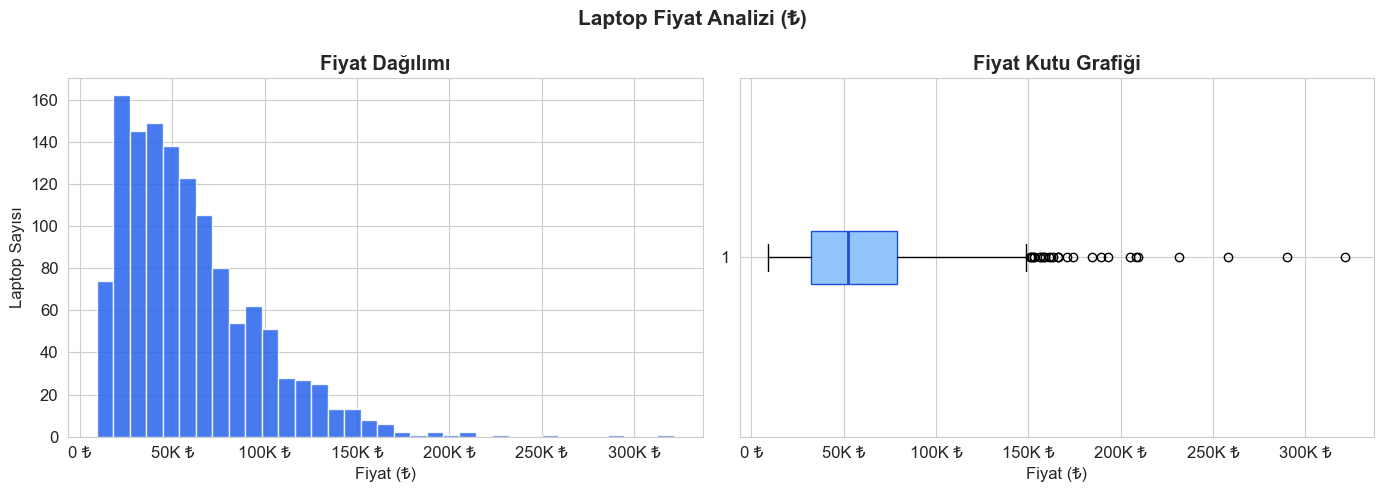

✅ fiyat_dagilimi_TL.png kaydedildi


In [8]:
def tl_fmt(x, _):
    return f'{x/1000:.0f}K ₺' if x >= 1000 else f'{x:.0f} ₺'

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Laptop Fiyat Analizi (₺)', fontsize=15, fontweight='bold')

# Histogram
axes[0].hist(df_clean[price_col], bins=35, color='#2563eb', edgecolor='white', alpha=0.85)
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(tl_fmt))
axes[0].set_title('Fiyat Dağılımı', fontweight='bold')
axes[0].set_xlabel('Fiyat (₺)')
axes[0].set_ylabel('Laptop Sayısı')

# Kutu grafiği
bp = axes[1].boxplot(df_clean[price_col], vert=False, patch_artist=True,
                boxprops=dict(facecolor='#93c5fd', color='#1d4ed8'),
                medianprops=dict(color='#1d4ed8', linewidth=2))
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(tl_fmt))
axes[1].set_title('Fiyat Kutu Grafiği', fontweight='bold')
axes[1].set_xlabel('Fiyat (₺)')

plt.tight_layout()
plt.savefig('fiyat_dagilimi_TL.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ fiyat_dagilimi_TL.png kaydedildi')

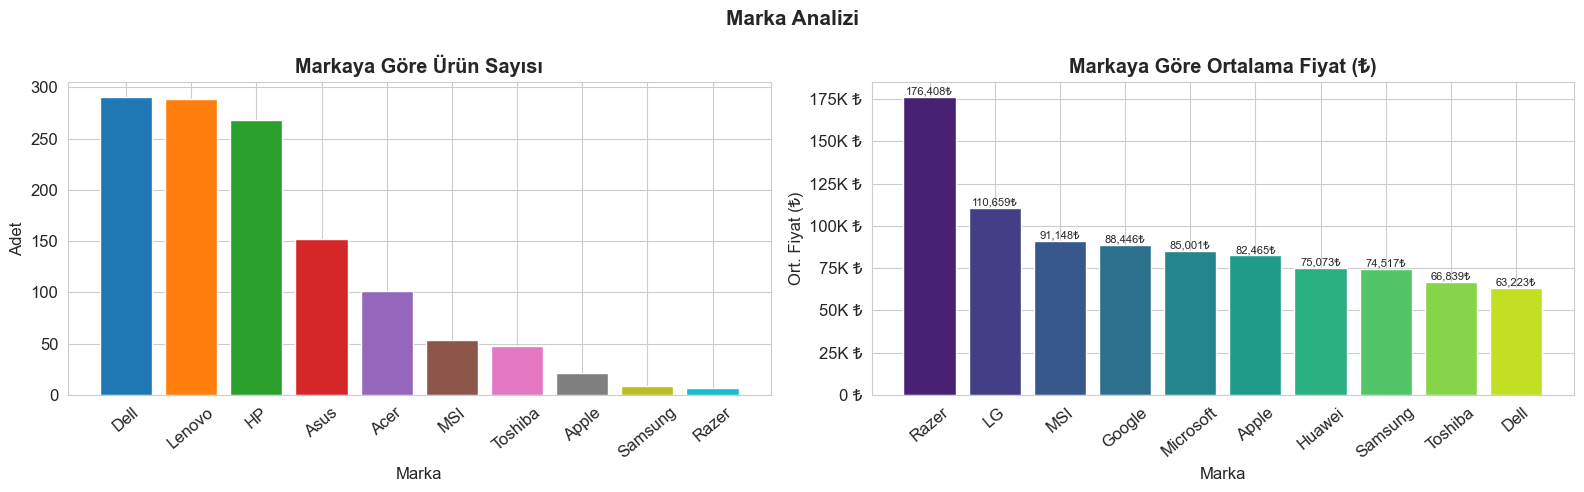

✅ marka_analiz_TL.png kaydedildi


In [9]:
if brand_col:
    avg_brand = (df_clean.groupby(brand_col)[price_col]
                 .mean().sort_values(ascending=False).head(10))
    cnt_brand = df_clean[brand_col].value_counts().head(10)

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    fig.suptitle('Marka Analizi', fontsize=15, fontweight='bold')

    palette = sns.color_palette('tab10', 10)

    axes[0].bar(cnt_brand.index, cnt_brand.values, color=palette)
    axes[0].set_title('Markaya Göre Ürün Sayısı', fontweight='bold')
    axes[0].set_xlabel('Marka'); axes[0].set_ylabel('Adet')
    axes[0].tick_params(axis='x', rotation=40)

    bars = axes[1].bar(avg_brand.index, avg_brand.values,
                       color=sns.color_palette('viridis',10))
    axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(tl_fmt))
    axes[1].set_title('Markaya Göre Ortalama Fiyat (₺)', fontweight='bold')
    axes[1].set_xlabel('Marka'); axes[1].set_ylabel('Ort. Fiyat (₺)')
    axes[1].tick_params(axis='x', rotation=40)
    for bar, val in zip(bars, avg_brand.values):
        axes[1].text(bar.get_x()+bar.get_width()/2,
                     bar.get_height()+300,
                     f'{val:,.0f}₺', ha='center', va='bottom', fontsize=8)

    plt.tight_layout()
    plt.savefig('marka_analiz_TL.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('✅ marka_analiz_TL.png kaydedildi')

In [13]:
df.columns

Index(['Company', 'Product', 'TypeName', 'Inches', 'ScreenResolution',
       'CPU_Company', 'CPU_Type', 'CPU_Frequency (GHz)', 'RAM (GB)', 'Memory',
       'GPU_Company', 'GPU_Type', 'OpSys', 'Weight (kg)', 'Price (Euro)',
       'Price_TL', 'SSD', 'HDD', 'CPU_Score', 'GPU_Score'],
      dtype='str')

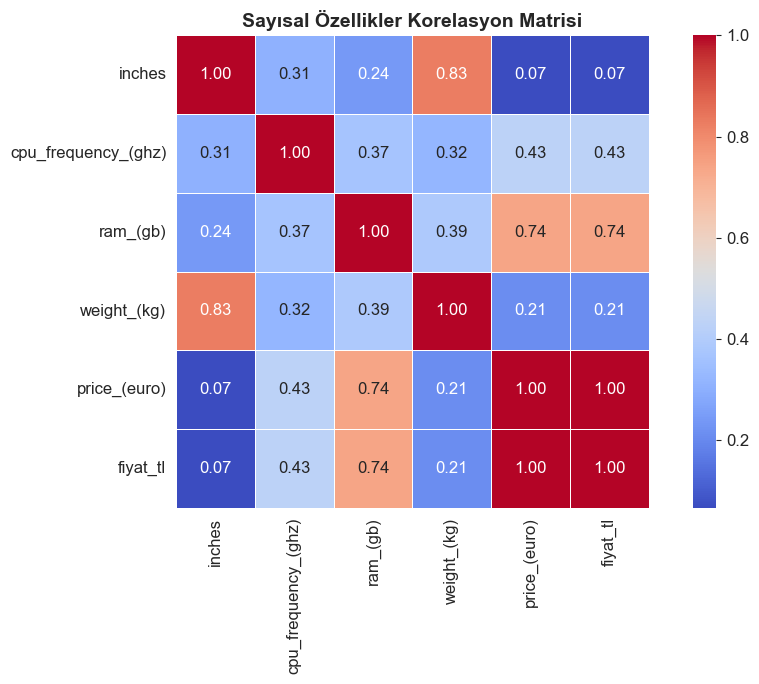

In [10]:
# Korelasyon ısı haritası (sayısal sütunlar)
num_cols = df_clean.select_dtypes('number').columns.tolist()
if len(num_cols) >= 2:
    corr = df_clean[num_cols].corr()
    plt.figure(figsize=(10, 7))
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
                linewidths=0.5, square=True)
    plt.title('Sayısal Özellikler Korelasyon Matrisi', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('korelasyon.png', dpi=150, bbox_inches='tight')
    plt.show()

In [11]:
# ── Fiyat segmentleri (₺) ───────────────────────────────────
q25 = df_clean[price_col].quantile(0.25)
q50 = df_clean[price_col].quantile(0.50)
q75 = df_clean[price_col].quantile(0.75)

print('💰 Fiyat Segmentleri (₺):')
print(f'   💚 Ekonomik   : {df_clean[price_col].min():>10,.0f} ₺  –  {q25:>10,.0f} ₺')
print(f'   🔵 Orta       : {q25:>10,.0f} ₺  –  {q50:>10,.0f} ₺')
print(f'   🟠 Üst Segment: {q50:>10,.0f} ₺  –  {q75:>10,.0f} ₺')
print(f'   🔴 Premium    : {q75:>10,.0f} ₺  –  {df_clean[price_col].max():>10,.0f} ₺')

💰 Fiyat Segmentleri (₺):
   💚 Ekonomik   :      9,173 ₺  –      32,106 ₺
   🔵 Orta       :     32,106 ₺  –      52,140 ₺
   🟠 Üst Segment:     52,140 ₺  –      78,896 ₺
   🔴 Premium    :     78,896 ₺  –     321,539 ₺


In [12]:
KULLANIM_PROFILLERI = {
    'oyun': {
        'ram': 0.30, 'depolama': 0.20, 'ekran': 0.20, 'cpu': 0.30, 'fiyat': 0.00,
        'emoji': '🎮', 'ad': 'Oyun'
    },
    'ofis': {
        'ram': 0.20, 'depolama': 0.20, 'ekran': 0.25, 'cpu': 0.15, 'fiyat': 0.20,
        'emoji': '📊', 'ad': 'Ofis / İş'
    },
    'grafik_tasarim': {
        'ram': 0.25, 'depolama': 0.15, 'ekran': 0.35, 'cpu': 0.25, 'fiyat': 0.00,
        'emoji': '🎨', 'ad': 'Grafik Tasarım'
    },
    'programlama': {
        'ram': 0.35, 'depolama': 0.25, 'ekran': 0.15, 'cpu': 0.25, 'fiyat': 0.00,
        'emoji': '💻', 'ad': 'Programlama'
    },
    'ogrenci': {
        'ram': 0.15, 'depolama': 0.20, 'ekran': 0.20, 'cpu': 0.15, 'fiyat': 0.30,
        'emoji': '📚', 'ad': 'Öğrenci'
    },
    'video_duzenleme': {
        'ram': 0.30, 'depolama': 0.30, 'ekran': 0.20, 'cpu': 0.20, 'fiyat': 0.00,
        'emoji': '🎬', 'ad': 'Video Düzenleme'
    }
}

def norm(s):
    mn, mx = s.min(), s.max()
    if mx == mn: return pd.Series([0.5]*len(s), index=s.index)
    return (s - mn) / (mx - mn)

def laptop_oneri(kullanim_amaci, butce_min_tl, butce_max_tl,
                 tercih_marka=None, min_ram_gb=None, n=5):
    """
    ₺ bütçeye göre laptop önerir.
    """
    if kullanim_amaci not in KULLANIM_PROFILLERI:
        print(f'Geçersiz profil! Seçenekler: {list(KULLANIM_PROFILLERI)}')
        return None

    w = KULLANIM_PROFILLERI[kullanim_amaci]
    flt = df_clean[(df_clean[price_col] >= butce_min_tl) &
                   (df_clean[price_col] <= butce_max_tl)].copy()

    if flt.empty:
        print(f'❌ {butce_min_tl:,.0f} ₺ – {butce_max_tl:,.0f} ₺ aralığında sonuç yok.')
        print(f'   Geçerli aralık: {df_clean[price_col].min():,.0f} ₺ – {df_clean[price_col].max():,.0f} ₺')
        return None

    # Marka filtresi
    if tercih_marka and brand_col:
        mf = flt[flt[brand_col].str.lower().str.contains(tercih_marka.lower(), na=False)]
        flt = mf if not mf.empty else flt

    flt['_skor'] = 0.0

    # RAM
    rc = next((c for c in flt.columns if 'ram' in c.lower()), None)
    if rc:
        flt[rc] = pd.to_numeric(flt[rc].astype(str).str.extract(r'(\d+)')[0], errors='coerce')
        flt['_skor'] += norm(flt[rc].fillna(0)) * w['ram']
        if min_ram_gb:
            flt = flt[flt[rc] >= min_ram_gb]

    # Depolama
    sc = next((c for c in flt.columns
               if any(x in c.lower() for x in ['storage','hdd','ssd','disk'])), None)
    if sc:
        flt[sc] = pd.to_numeric(flt[sc].astype(str).str.extract(r'(\d+)')[0], errors='coerce')
        flt['_skor'] += norm(flt[sc].fillna(0)) * w['depolama']

    # Ekran
    ec = next((c for c in flt.columns
               if any(x in c.lower() for x in ['screen','display','inch','size'])), None)
    if ec:
        flt[ec] = pd.to_numeric(flt[ec].astype(str).str.extract(r'([\d.]+)')[0], errors='coerce')
        flt['_skor'] += norm(flt[ec].fillna(0)) * w['ekran']

    # Fiyat ekonomisi
    flt['_skor'] += (1 - norm(flt[price_col])) * w['fiyat']

    if flt.empty:
        print('Filtreler sonrası sonuç bulunamadı.')
        return None

    return flt.nlargest(n, '_skor')

print('✅ Öneri motoru hazır!')

✅ Öneri motoru hazır!


In [16]:
def goster(df_res, kullanim_amaci):
    if df_res is None or df_res.empty:
        print('Sonuç yok.'); return
    p = KULLANIM_PROFILLERI[kullanim_amaci]
    print('═'*65)
    print(f"  {p['emoji']}  {p['ad'].upper()} İÇİN EN UYGUN LAPTOP ÖNERİLERİ")
    print('═'*65)
    for i, (_, row) in enumerate(df_res.iterrows(), 1):
        print(f'\n  ── #{i} ──────────────────────────────────────')
        for col in df_res.columns:
            if col == '_skor':
                print(f'     ⭐ Uyum Skoru : {row[col]:.4f}')
            elif col == price_col:
                print(f'     💰 Fiyat (₺)  : {row[col]:,.0f} ₺')
            elif col == price_eur_col:
                print(f'     💶 Fiyat (€)   : {row[col]:.2f} €')
            else:
                print(f'     📌 {col.replace("_"," ").title():<12}: {row[col]}')
    print('\n' + '═'*65)

In [17]:
# 🎮 OYUN — orta-üst bütçe
r1 = laptop_oneri('oyun', butce_min_tl=30_000, butce_max_tl=80_000, n=3)
goster(r1, 'oyun')

═════════════════════════════════════════════════════════════════
  🎮  OYUN İÇİN EN UYGUN LAPTOP ÖNERİLERİ
═════════════════════════════════════════════════════════════════

  ── #1 ──────────────────────────────────────
     📌 Company     : Asus
     📌 Product     : G701VO-IH74K (i7-6820HK/32GB/2x
     📌 Typename    : Gaming
     📌 Inches      : 17.3
     📌 Screenresolution: IPS Panel Full HD 1920x1080
     📌 Cpu Company : Intel
     📌 Cpu Type    : Core i7 6820HK
     📌 Cpu Frequency (Ghz): 2.7
     📌 Ram (Gb)    : 32
     📌 Memory      : 256GB SSD +  256GB SSD
     📌 Gpu Company : Nvidia
     📌 Gpu Type    : GeForce GTX 980M
     📌 Opsys       : Windows 10
     📌 Weight (Kg) : 3.58
     💶 Fiyat (€)   : 1279.00 €
     💰 Fiyat (₺)  : 67,429 ₺
     ⭐ Uyum Skoru : 0.5000

  ── #2 ──────────────────────────────────────
     📌 Company     : Asus
     📌 Product     : Rog G752VL-UH71T
     📌 Typename    : Gaming
     📌 Inches      : 17.3
     📌 Screenresolution: IPS Panel Full HD / Touchscr

In [18]:
# 📚 ÖĞRENCİ — ekonomik
r2 = laptop_oneri('ogrenci', butce_min_tl=10_000, butce_max_tl=30_000, n=3)
goster(r2, 'ogrenci')

═════════════════════════════════════════════════════════════════
  📚  ÖĞRENCI İÇİN EN UYGUN LAPTOP ÖNERİLERİ
═════════════════════════════════════════════════════════════════

  ── #1 ──────────────────────────────────────
     📌 Company     : Lenovo
     📌 Product     : IdeaPad 110-15IBR
     📌 Typename    : Notebook
     📌 Inches      : 15.6
     📌 Screenresolution: 1366x768
     📌 Cpu Company : Intel
     📌 Cpu Type    : Celeron Quad Core N3710
     📌 Cpu Frequency (Ghz): 1.6
     📌 Ram (Gb)    : 8
     📌 Memory      : 1TB HDD
     📌 Gpu Company : Intel
     📌 Gpu Type    : HD Graphics 405
     📌 Opsys       : No OS
     📌 Weight (Kg) : 2.2
     💶 Fiyat (€)   : 329.00 €
     💰 Fiyat (₺)  : 17,345 ₺
     ⭐ Uyum Skoru : 0.4937

  ── #2 ──────────────────────────────────────
     📌 Company     : Acer
     📌 Product     : Chromebook 15
     📌 Typename    : Notebook
     📌 Inches      : 15.6
     📌 Screenresolution: 1366x768
     📌 Cpu Company : Intel
     📌 Cpu Type    : Celeron Dual C

In [19]:
# 💻 PROGRAMLAMA — orta bütçe, min 16 GB RAM
r3 = laptop_oneri('programlama', butce_min_tl=25_000, butce_max_tl=65_000,
                  min_ram_gb=16, n=3)
goster(r3, 'programlama')

═════════════════════════════════════════════════════════════════
  💻  PROGRAMLAMA İÇİN EN UYGUN LAPTOP ÖNERİLERİ
═════════════════════════════════════════════════════════════════

  ── #1 ──────────────────────────────────────
     📌 Company     : HP
     📌 Product     : Envy 17-U275cl
     📌 Typename    : Notebook
     📌 Inches      : 17.3
     📌 Screenresolution: IPS Panel Full HD 1920x1080
     📌 Cpu Company : Intel
     📌 Cpu Type    : Core i7 8550U
     📌 Cpu Frequency (Ghz): 1.8
     📌 Ram (Gb)    : 16
     📌 Memory      : 1TB HDD
     📌 Gpu Company : Nvidia
     📌 Gpu Type    : GeForce MX150
     📌 Opsys       : Windows 10
     📌 Weight (Kg) : 2.9
     💶 Fiyat (€)   : 1059.00 €
     💰 Fiyat (₺)  : 55,830 ₺
     ⭐ Uyum Skoru : 0.5000

  ── #2 ──────────────────────────────────────
     📌 Company     : Asus
     📌 Product     : Rog G752VL-GC088D
     📌 Typename    : Gaming
     📌 Inches      : 17.3
     📌 Screenresolution: IPS Panel Full HD 1920x1080
     📌 Cpu Company : Intel
  

In [ ]:
def interaktif():
    print('='*60)
    print('  💻 LAPTOP ÖNERİ SİSTEMİ  |  ₺ Türk Lirası')
    print('='*60)

    # Kullanım amacı
    secenekler = list(KULLANIM_PROFILLERI.keys())
    print('\n📌 KULLANIM AMACI:')
    for i,(k,v) in enumerate(KULLANIM_PROFILLERI.items(),1):
        print(f'   {i}. {v["emoji"]} {v["ad"]}')
    while True:
        try:
            s = int(input('Seçim (1-6): '))
            if 1<=s<=len(secenekler): kullanim=secenekler[s-1]; break
        except: pass
        print('Lütfen 1-6 arası girin.')
    print(f'✅ {KULLANIM_PROFILLERI[kullanim]["emoji"]} {KULLANIM_PROFILLERI[kullanim]["ad"]} seçildi.')

    # Bütçe (₺)
    print(f'\n💰 BÜTÇE (₺)  |  Aralık: {df_clean[price_col].min():,.0f} ₺ – {df_clean[price_col].max():,.0f} ₺')
    while True:
        try:
            mn = float(input('  Min bütçe (₺): ').replace(',','.'))
            mx = float(input('  Max bütçe (₺): ').replace(',','.'))
            if mn < mx: break
            print('Min < Max olmalı!')
        except: print('Sayı girin.')

    # Marka
    if brand_col:
        markalar = df_clean[brand_col].value_counts().head(10).index.tolist()
        print(f'\n🏷️  MARKA (boş = fark etmez) | Örnek: {markalar[:5]}')
        marka = input('  Marka: ').strip() or None
    else:
        marka = None

    # Min RAM
    ram_girdi = input('\n🧠 Min RAM (GB, boş = fark etmez): ').strip()
    min_ram = int(ram_girdi) if ram_girdi.isdigit() else None

    # Öneri sayısı
    n_str = input('\n📋 Kaç öneri? (varsayılan 5): ').strip()
    n = int(n_str) if n_str.isdigit() else 5

    print('\n⏳ Hesaplanıyor...')
    res = laptop_oneri(kullanim, mn, mx, marka, min_ram, n)
    goster(res, kullanim)
    return res

# ▶️  Başlat
son_oneri = interaktif()

  💻 LAPTOP ÖNERİ SİSTEMİ  |  ₺ Türk Lirası

📌 KULLANIM AMACI:
   1. 🎮 Oyun
   2. 📊 Ofis / İş
   3. 🎨 Grafik Tasarım
   4. 💻 Programlama
   5. 📚 Öğrenci
   6. 🎬 Video Düzenleme


In [ ]:
def interaktif_oneri():
    """
    Kullanıcıdan bilgi alarak interaktif öneri sunar.
    """
    print('=' * 60)
    print('🖥️  LAPTOP ÖNERİ SİSTEMİ - HOŞ GELDİNİZ!')
    print('=' * 60)
    print()
    
    # Kullanım amacı
    print('📌 KULLANIM AMACINIZI SEÇİN:')
    secenekler = list(KULLANIM_PROFILLERI.keys())
    for i, (k, v) in enumerate(KULLANIM_PROFILLERI.items(), 1):
        print(f'   {i}. {v["aciklama"]}')
    
    while True:
        try:
            secim = int(input('\nSeçiminiz (1-6): '))
            if 1 <= secim <= len(secenekler):
                kullanim = secenekler[secim - 1]
                print(f'✅ Seçilen: {KULLANIM_PROFILLERI[kullanim]["aciklama"]}')
                break
            else:
                print('⚠️  Lütfen 1-6 arasında bir sayı girin.')
        except ValueError:
            print('⚠️  Lütfen sayı girin.')
    
    # Bütçe
    print(f'\n💰 BÜTÇE ARALINIZI GİRİN:')
    print(f'   (Mevcut aralık: {df_clean[price_column].min():.0f} - {df_clean[price_column].max():.0f})')
    
    while True:
        try:
            min_butce = float(input('   Minimum bütçe: '))
            max_butce = float(input('   Maksimum bütçe: '))
            if min_butce < max_butce:
                break
            print('⚠️  Minimum bütçe maksimumdan küçük olmalı!')
        except ValueError:
            print('⚠️  Lütfen sayı girin.')
    
    # Marka tercihi
    print('\n🏷️  MARKA TERCİHİ (boş bırakabilirsiniz):')
    if brand_column:
        markalar = df_clean[brand_column].value_counts().head(10).index.tolist()
        print(f'   Mevcut markalar: {markalar[:8]}')
        marka = input('   Tercih ettiğiniz marka (Enter = fark etmez): ').strip()
        marka = marka if marka else None
    else:
        marka = None
    
    # Minimum RAM
    print('\n🧠 MİNİMUM RAM (GB cinsinden, boş = fark etmez):')
    ram_girdi = input('   Minimum RAM GB: ').strip()
    min_ram = float(ram_girdi) if ram_girdi.isdigit() else None
    
    # Öneri sayısı
    oneri_sayisi_girdi = input('\n📊 Kaç öneri görmek istersiniz? (varsayılan 5): ').strip()
    oneri_sayisi = int(oneri_sayisi_girdi) if oneri_sayisi_girdi.isdigit() else 5
    
    print('\n⏳ Öneri hesaplanıyor...')
    
    # Öneri yap
    sonuc = laptop_oneri_sistemi(
        df=df_clean,
        kullanim_amaci=kullanim,
        butce_min=min_butce,
        butce_max=max_butce,
        tercih_marka=marka,
        min_ram=min_ram,
        oneri_sayisi=oneri_sayisi
    )
    
    sonuclari_goster(sonuc, kullanim)
    return sonuc


# ▶️ Sistemi başlat!
oneri_sonuclari = interaktif_oneri()

🖥️  LAPTOP ÖNERİ SİSTEMİ - HOŞ GELDİNİZ!

📌 KULLANIM AMACINIZI SEÇİN:
   1. 🎮 Oyun - Yüksek RAM ve güçlü işlemci öncelikli
   2. 📊 Ofis - Verimlilik ve ekonomi öncelikli
   3. 🎨 Grafik Tasarım - Ekran kalitesi ve RAM öncelikli
   4. 💻 Programlama - RAM ve işlemci öncelikli
   5. 📚 Öğrenci - Ekonomi ve dayanıklılık öncelikli
   6. 🎬 Video Düzenleme - Depolama ve RAM öncelikli


In [2]:
def gorsellestir(res, baslik='Öneri Sonuçları'):
    if res is None or res.empty: print('Sonuç yok.'); return

    if brand_col and brand_col in res.columns:
        etiket = [f"{r[brand_col]}\n{r[price_col]:,.0f}₺" for _,r in res.iterrows()]
    else:
        etiket = [f'#{i+1}\n{r[price_col]:,.0f}₺' for i,(_,r) in enumerate(res.iterrows())]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14,6))
    fig.suptitle(f'📊 {baslik}', fontsize=15, fontweight='bold')

    # Uyum skoru
    c1 = sns.color_palette('RdYlGn', len(res))
    bars1 = ax1.bar(range(len(res)), res['_skor'], color=c1, edgecolor='white')
    ax1.set_xticks(range(len(res))); ax1.set_xticklabels(etiket, ha='center', fontsize=9)
    ax1.set_title('⭐ Uyum Skoru', fontweight='bold'); ax1.set_ylabel('Skor')
    for b,v in zip(bars1, res['_skor']):
        ax1.text(b.get_x()+b.get_width()/2, b.get_height()+0.003,
                 f'{v:.3f}', ha='center', fontsize=9, fontweight='bold')

    # Fiyat
    c2 = sns.color_palette('Blues_r', len(res))
    bars2 = ax2.bar(range(len(res)), res[price_col], color=c2, edgecolor='white')
    ax2.yaxis.set_major_formatter(mticker.FuncFormatter(tl_fmt))
    ax2.set_xticks(range(len(res))); ax2.set_xticklabels(etiket, ha='center', fontsize=9)
    ax2.set_title('💰 Fiyat Karşılaştırması (₺)', fontweight='bold'); ax2.set_ylabel('Fiyat (₺)')
    for b,v in zip(bars2, res[price_col]):
        ax2.text(b.get_x()+b.get_width()/2, b.get_height()+200,
                 f'{v:,.0f}₺', ha='center', fontsize=9, fontweight='bold')

    plt.tight_layout()
    plt.savefig('oneri_gorseli.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('✅ oneri_gorseli.png kaydedildi')

if 'son_oneri' in dir():
    gorsellestir(son_oneri, 'Laptop Önerilerim')